# 01: Discovery Quality Problem Setup and EDA

This notebook starts the discovery-quality mediation workflow using KuaiRec.

The causal problem is that short-term interaction metrics do not necessarily measure durable user value. A recommendation exposure can create immediate engagement and still fail to improve satisfaction or future activity. For discovery systems, this distinction matters because a metric such as CTR or interaction volume can reward curiosity, novelty, or low-friction behavior without proving that users were satisfied.

The workflow studies the pathway:

`Exposure -> Immediate engagement -> Satisfaction -> Future engagement`

This first notebook prepares the data and clarifies the measurement problem.

- What signals exist in KuaiRec?
- Which columns can represent exposure, immediate engagement, satisfaction, and future value?
- How can we define a discovery-oriented exposure using long-tail or new-category content?
- Is there enough variation to support a later mediation analysis?

## Dataset Field Guide

KuaiRec is stored locally as a zip file that contains another `KuaiRec.zip` archive. The main files used in this workflow are below.

### User-Video Interaction Logs

These are user-video interaction matrices. `small_matrix.csv` is used here because it is large enough for realistic EDA but small enough to process quickly.

- `user_id`: anonymized user identifier.
- `video_id`: anonymized video identifier.
- `play_duration`: watched time in milliseconds.
- `video_duration`: video length in milliseconds.
- `time`: interaction timestamp as a readable datetime string.
- `date`: calendar date in `YYYYMMDD` form.
- `timestamp`: Unix timestamp for the interaction.
- `watch_ratio`: `play_duration / video_duration`. Values can exceed 1 when a user rewatches, loops, or spends longer than the nominal video duration.

### User Metadata

This file contains anonymized user profile and activity features.

- `user_id`: anonymized user identifier.
- `user_active_degree`: categorical user activity level.
- `is_lowactive_period`: whether the user is in a low-activity period.
- `is_live_streamer`: whether the user is marked as a live streamer.
- `is_video_author`: whether the user has authored videos.
- `follow_user_num`: count of followed users.
- `follow_user_num_range`: binned follow count.
- `fans_user_num`: count of fans.
- `fans_user_num_range`: binned fan count.
- `friend_user_num`: count of friends.
- `friend_user_num_range`: binned friend count.
- `register_days`: days since registration.
- `register_days_range`: binned registration age.
- `onehot_feat0` through `onehot_feat17`: anonymized categorical or profile features encoded as integers. The raw feature meanings are not provided, so they should be used as controls with limited interpretation.

### Video Category Metadata

This file maps videos to category feature IDs.

- `video_id`: anonymized video identifier.
- `feat`: list-like category feature IDs for the video.

### Caption and Category Metadata

This file provides richer video metadata.

- `video_id`: anonymized video identifier.
- `manual_cover_text`: text shown on the video cover when available.
- `caption`: video caption text when available.
- `topic_tag`: list-like topic tags.
- `first_level_category_id`: broad category ID.
- `first_level_category_name`: broad category name.
- `second_level_category_id`: mid-level category ID.
- `second_level_category_name`: mid-level category name.
- `third_level_category_id`: fine category ID.
- `third_level_category_name`: fine category name.

### Daily Item Popularity and Platform Context

This file contains daily aggregate item metrics. It is useful for item-level popularity and platform-level context.

- Identity and item state: `video_id`, `date`, `author_id`, `video_type`, `upload_dt`, `upload_type`, `visible_status`, `video_duration`, `video_width`, `video_height`, `music_id`, `video_tag_id`, `video_tag_name`.
- Exposure and play counts: `show_cnt`, `show_user_num`, `play_cnt`, `play_user_num`, `play_duration`, `complete_play_cnt`, `complete_play_user_num`, `valid_play_cnt`, `valid_play_user_num`, `long_time_play_cnt`, `long_time_play_user_num`, `short_time_play_cnt`, `short_time_play_user_num`, `play_progress`.
- Engagement actions: `comment_stay_duration`, `like_cnt`, `like_user_num`, `click_like_cnt`, `double_click_cnt`, `cancel_like_cnt`, `cancel_like_user_num`, `comment_cnt`, `comment_user_num`, `direct_comment_cnt`, `reply_comment_cnt`, `delete_comment_cnt`, `delete_comment_user_num`, `comment_like_cnt`, `comment_like_user_num`, `follow_cnt`, `follow_user_num`, `cancel_follow_cnt`, `cancel_follow_user_num`, `share_cnt`, `share_user_num`, `download_cnt`, `download_user_num`.
- Negative or corrective feedback: `report_cnt`, `report_user_num`, `reduce_similar_cnt`, `reduce_similar_user_num`.
- Collection actions: `collect_cnt`, `collect_user_num`, `cancel_collect_cnt`, `cancel_collect_user_num`.

## Causal Measurement Setup

For this project, the first version of the mediation setup uses:

- **Treatment candidate**: high discovery exposure on a user-day, measured by a high share of long-tail or new-category videos.
- **Immediate engagement mediator**: valid play share or interaction intensity on the same day.
- **Satisfaction mediator**: average watch ratio, high-watch share, or completion/rewatch share.
- **Future outcome**: future 7-day interactions, active days, and play time.

The later mediation notebooks will formalize assumptions and estimate direct, indirect, and total effects.


## Project Framing

### What You Will Build

This project builds a mediation analysis workflow for discovery quality in recommendation systems. You will construct discovery exposure, satisfaction-depth mediators, future engagement outcomes, and robustness checks, then estimate direct, indirect, and total effects with classical, SEM-style, and machine-learning mediation approaches.

### How To Use This Project

Work through the notebooks in order. This first notebook sets up the discovery-quality problem and prepares the user-day data. Later notebooks validate the metrics, state mediation assumptions, estimate pathways, test robustness, and compare advanced mediation models. The final notebook builds report figures and writeup artifacts.

### Data Source And Scope

The project uses KuaiRec watch behavior and user-video interaction logs. The data are reorganized into active user-day records so the analysis can connect discovery breadth, satisfaction depth, and future engagement. Because the design is observational, the project emphasizes metric validity, mediator assumptions, overlap, and sensitivity.

<!-- dataset-experiment-context -->
## Dataset and Mediation Design Context

This project uses KuaiRec interaction logs and metadata organized into active user-day records. The workflow constructs discovery-breadth, satisfaction-depth, quality-adjusted discovery, and shallow-click-pressure metrics from logged viewing behavior.

This is a real observational recommendation log, not a randomized mediation experiment. The treatment is high discovery-breadth exposure, the mediator is same-day satisfaction depth, and the primary outcome is future seven-day interactions.

The project asks whether discovery exposure relates to future value directly, indirectly through satisfaction depth, or both. Because mediation in observational logs requires strong assumptions, the notebooks emphasize metric construction, temporal ordering, overlap, placebo-style checks, robustness across definitions, and model sensitivity.

**Role of this notebook.** This notebook builds the KuaiRec active user-day panel and motivates why discovery exposure, satisfaction depth, and future value should be separated.

<!-- mathematical-setup -->

## Mathematical Setup

Mediation analysis separates a treatment effect into pathways. Let \(A_i\) be high discovery exposure, \(M_i\) a satisfaction-depth mediator, and \(Y_i\) a later engagement outcome. The total effect is

$$
\tau_{\text{total}}=\mathbb{E}[Y_i(1)-Y_i(0)].
$$

A mediation question asks how much of this effect operates through \(M_i\). The EDA therefore checks all three pieces of the pathway:

$$
A_i \rightarrow M_i \rightarrow Y_i.
$$

The notebook does not treat this diagram as proof. It uses it to organize measurement, timing, and candidate confounders before formal estimation.


#### 1. Environment and Paths

This cell imports the libraries used for the setup notebook. It also finds the repository root by searching for the local KuaiRec zip file, then creates project-specific writeup folders for figures and tables.


In [1]:
# Set up environment and paths.
from io import BytesIO
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_DIR = next(
    root for root in candidate_roots
    if (root / "data" / "Kuairec" / "18164998.zip").exists()
)

DATA_DIR = PROJECT_DIR / "data"
RAW_ZIP = DATA_DIR / "Kuairec" / "18164998.zip"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "discovery_quality_mediation"
WRITEUP_DIR = NOTEBOOK_DIR / "writeup"
FIGURE_DIR = WRITEUP_DIR / "figures"
TABLE_DIR = WRITEUP_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RAW_ZIP.exists(), RAW_ZIP


(True, PosixPath('/home/apex/Documents/portfolio/data/Kuairec/18164998.zip'))

The path check should return `True`. The notebook will read from the local KuaiRec archive and save processed discovery-quality artifacts under `data/processed`. This keeps the analysis auditable: a reader can trace the final claim back to the exact table, figure, or markdown artifact that produced it.


#### 2. Inspect the KuaiRec Archive

KuaiRec is distributed as an outer zip that contains a nested `KuaiRec.zip`. This cell lists the outer files and the nested files so the notebook documents exactly which local data assets are being used.


In [2]:
# Inspect the KuaiRec archive.
with ZipFile(RAW_ZIP) as outer_zip:
    outer_files = pd.DataFrame(
        [
            {
                "file": info.filename,
                "uncompressed_mb": info.file_size / 1_000_000,
                "compressed_mb": info.compress_size / 1_000_000,
            }
            for info in outer_zip.infolist()
            if not info.is_dir()
        ]
    )
    nested_bytes = outer_zip.read("KuaiRec.zip")

with ZipFile(BytesIO(nested_bytes)) as inner_zip:
    nested_files = pd.DataFrame(
        [
            {
                "file": info.filename,
                "uncompressed_mb": info.file_size / 1_000_000,
                "compressed_mb": info.compress_size / 1_000_000,
            }
            for info in inner_zip.infolist()
            if not info.is_dir()
        ]
    ).sort_values("uncompressed_mb", ascending=False)

display(outer_files)
display(nested_files)


,file,uncompressed_mb,compressed_mb
0,KuaiRec.zip,431.9649,431.9649
1,kuairec_caption_category.csv,1.9646,1.9646
2,video_raw_categories_multi.csv,1.7245,1.7245
3,user_features_raw.csv,1.5416,1.5416


,file,uncompressed_mb,compressed_mb
2,KuaiRec 2.0/data/big_matrix.csv,"1,083.5212",292.5965
6,KuaiRec 2.0/data/small_matrix.csv,406.1558,119.1462
4,KuaiRec 2.0/data/item_daily_features.csv,85.8552,19.0098
5,KuaiRec 2.0/data/kuairec_caption_category.csv,1.9646,0.6010
8,KuaiRec 2.0/data/user_features.csv,0.7442,0.1223
1,KuaiRec 2.0/Statistics_KuaiRec.ipynb,0.3142,0.1893
9,KuaiRec 2.0/figs/KuaiRec.png,0.3002,0.2551
3,KuaiRec 2.0/data/item_categories.csv,0.1131,0.0315
0,KuaiRec 2.0/LICENSE,0.0201,0.0060
7,KuaiRec 2.0/data/social_network.csv,0.0069,0.0030


The archive inspection shows why `small_matrix.csv` is the right starting point. It is a substantial interaction table, while `big_matrix.csv` is much larger. The metadata tables are small enough to load fully or with selected columns.


#### 3. Load Metadata Tables

This cell loads user features, video category metadata, and selected daily item aggregate columns. These tables provide context for discovery-quality analysis: user controls, video categories, and item popularity signals.


In [3]:
# Load metadata tables.
with ZipFile(BytesIO(nested_bytes)) as inner_zip:
    with inner_zip.open("KuaiRec 2.0/data/user_features.csv") as file:
        user_features = pd.read_csv(file)
    with inner_zip.open("KuaiRec 2.0/data/item_categories.csv") as file:
        item_categories = pd.read_csv(file)
    caption_cols = [
        "video_id",
        "first_level_category_id",
        "first_level_category_name",
        "second_level_category_id",
        "second_level_category_name",
        "third_level_category_id",
        "third_level_category_name",
    ]
    with inner_zip.open("KuaiRec 2.0/data/kuairec_caption_category.csv") as file:
        caption_categories = pd.read_csv(
            file,
            usecols=caption_cols,
            engine="python",
            on_bad_lines="skip",
        )
    item_daily_cols = [
        "video_id",
        "date",
        "video_duration",
        "show_cnt",
        "show_user_num",
        "play_cnt",
        "play_user_num",
        "complete_play_cnt",
        "valid_play_cnt",
        "long_time_play_cnt",
        "short_time_play_cnt",
        "play_progress",
        "like_cnt",
        "comment_cnt",
        "follow_cnt",
        "share_cnt",
        "collect_cnt",
        "report_cnt",
        "reduce_similar_cnt",
        "video_tag_name",
    ]
    with inner_zip.open("KuaiRec 2.0/data/item_daily_features.csv") as file:
        item_daily = pd.read_csv(file, usecols=item_daily_cols)

for metadata_df in [user_features, item_categories, caption_categories, item_daily]:
    if "user_id" in metadata_df.columns:
        metadata_df["user_id"] = pd.to_numeric(metadata_df["user_id"], errors="coerce").astype("Int64")
    if "video_id" in metadata_df.columns:
        metadata_df["video_id"] = pd.to_numeric(metadata_df["video_id"], errors="coerce").astype("Int64")

item_categories = item_categories.dropna(subset=["video_id"]).copy()
caption_categories = caption_categories.dropna(subset=["video_id"]).copy()
item_daily = item_daily.dropna(subset=["video_id"]).copy()
item_categories["video_id"] = item_categories["video_id"].astype("int32")
caption_categories["video_id"] = caption_categories["video_id"].astype("int32")
item_daily["video_id"] = item_daily["video_id"].astype("int32")

metadata_summary = pd.DataFrame(
    {
        "table": ["user_features", "item_categories", "caption_categories", "item_daily_selected"],
        "rows": [len(user_features), len(item_categories), len(caption_categories), len(item_daily)],
        "columns": [user_features.shape[1], item_categories.shape[1], caption_categories.shape[1], item_daily.shape[1]],
        "unique_users": [user_features["user_id"].nunique(), np.nan, np.nan, np.nan],
        "unique_videos": [np.nan, item_categories["video_id"].nunique(), caption_categories["video_id"].nunique(), item_daily["video_id"].nunique()],
    }
)

display(metadata_summary)
display(user_features.head())
display(caption_categories.head())


,table,rows,columns,unique_users,unique_videos
0,user_features,7176,31,"7,176.0000",NaN
1,item_categories,10728,2,NaN,"10,728.0000"
2,caption_categories,10728,7,NaN,"10,728.0000"
3,item_daily_selected,343341,20,NaN,"10,728.0000"


,user_id,user_active_degree,is_lowactive_period,is_live_streamer,is_video_author,follow_user_num,follow_user_num_range,fans_user_num,fans_user_num_range,friend_user_num,friend_user_num_range,register_days,register_days_range,onehot_feat0,onehot_feat1,onehot_feat2,onehot_feat3,onehot_feat4,onehot_feat5,onehot_feat6,onehot_feat7,onehot_feat8,onehot_feat9,onehot_feat10,onehot_feat11,onehot_feat12,onehot_feat13,onehot_feat14,onehot_feat15,onehot_feat16,onehot_feat17
0,0,high_active,0,0,0,5,"(0,10]",0,0,0,0,107,61-90,0,1,17,638,2.0000,0,1,6,184,6,3,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,1,full_active,0,0,0,386,"(250,500]",4,"[1,10)",2,"[1,5)",327,181-365,0,3,25,1021,0.0000,0,1,6,186,6,2,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,2,full_active,0,0,0,27,"(10,50]",0,0,0,0,116,91-180,0,6,8,402,0.0000,0,0,2,51,2,3,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,3,full_active,0,0,0,16,"(10,50]",0,0,0,0,105,61-90,0,1,8,281,0.0000,0,0,34,251,3,2,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,4,full_active,0,0,0,122,"(100,150]",4,"[1,10)",0,0,225,181-365,0,1,8,316,1.0000,0,1,46,99,4,2,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


,video_id,first_level_category_id,first_level_category_name,second_level_category_id,second_level_category_name,third_level_category_id,third_level_category_name
0,0,8.0000,颜值,673.0000,颜值随拍,-124.0000,UNKNOWN
1,1,27.0000,高新数码,-124.0000,UNKNOWN,-124.0000,UNKNOWN
2,2,9.0000,喜剧,727.0000,搞笑互动,-124.0000,UNKNOWN
3,3,26.0000,摄影,686.0000,主题摄影,"2,434.0000",景物摄影
4,4,5.0000,时尚,737.0000,营销售卖,"2,596.0000",女装


The metadata tables give the controls and content context needed for mediation. User features help describe who is active. Category metadata lets us define new-category or diverse-discovery exposure. Item daily aggregates help define long-tail content more carefully than row counts alone.


### Build a Deterministic Interaction Sample

This cell scans `small_matrix.csv` in chunks and keeps complete interaction histories for users whose `user_id` is divisible by a fixed modulus. Sampling complete users is better than sampling random rows because later mediation analysis needs user-day histories and future outcomes.

The scan also records full-file row counts, unique users, unique videos, and timestamp coverage.


In [4]:
# Build a deterministic interaction sample.
USER_SAMPLE_MODULUS = 10
INTERACTION_CHUNK_ROWS = 750_000

interaction_dtypes = {
    "user_id": "int32",
    "video_id": "int32",
    "play_duration": "int32",
    "video_duration": "int32",
    "date": "float64",
    "timestamp": "float64",
    "watch_ratio": "float32",
}

sample_chunks = []
full_rows = 0
all_users = set()
all_videos = set()
timestamp_min = np.inf
timestamp_max = -np.inf

with ZipFile(BytesIO(nested_bytes)) as inner_zip:
    with inner_zip.open("KuaiRec 2.0/data/small_matrix.csv") as file:
        for chunk in pd.read_csv(file, chunksize=INTERACTION_CHUNK_ROWS, dtype=interaction_dtypes):
            full_rows += len(chunk)
            all_users.update(chunk["user_id"].unique().tolist())
            all_videos.update(chunk["video_id"].unique().tolist())
            timestamp_min = min(timestamp_min, chunk["timestamp"].min())
            timestamp_max = max(timestamp_max, chunk["timestamp"].max())

            sample = chunk.loc[chunk["user_id"] % USER_SAMPLE_MODULUS == 0].copy()
            if not sample.empty:
                sample_chunks.append(sample)

interactions = pd.concat(sample_chunks, ignore_index=True)

sample_summary = pd.DataFrame(
    {
        "metric": [
            "full_rows_scanned",
            "full_unique_users",
            "full_unique_videos",
            "full_timestamp_min",
            "full_timestamp_max",
            "sample_modulus",
            "sample_rows",
            "sample_unique_users",
            "sample_unique_videos",
        ],
        "value": [
            full_rows,
            len(all_users),
            len(all_videos),
            pd.to_datetime(timestamp_min, unit="s"),
            pd.to_datetime(timestamp_max, unit="s"),
            USER_SAMPLE_MODULUS,
            len(interactions),
            interactions["user_id"].nunique(),
            interactions["video_id"].nunique(),
        ],
    }
)

display(sample_summary)
display(interactions.head())


,metric,value
0,full_rows_scanned,4676570
1,full_unique_users,1411
2,full_unique_videos,3327
3,full_timestamp_min,2020-07-03 18:23:26.059999943
4,full_timestamp_max,2020-09-05 15:57:23.683000088
5,sample_modulus,10
6,sample_rows,440788
7,sample_unique_users,133
8,sample_unique_videos,3327


,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio
0,120,5228,7174,9900,2020-07-05 07:01:50.19,"20,200,705.0000","1,593,903,710.1900",0.7246
1,120,6788,4685,14934,2020-07-05 07:05:40.676,"20,200,705.0000","1,593,903,940.6760",0.3137
2,120,8207,4923,13834,2020-07-05 07:39:22.913,"20,200,705.0000","1,593,905,962.9130",0.3559
3,120,1936,3834,7100,2020-07-05 08:24:57.112,"20,200,705.0000","1,593,908,697.1120",0.5400
4,120,5266,6110,7074,2020-07-05 08:34:43.594,"20,200,705.0000","1,593,909,283.5940",0.8637


The sample keeps a meaningful number of users and interactions while remaining fast to work with. Because we sampled users, each sampled user can contribute a coherent daily sequence for future outcome construction.


#### 5. Clean Interaction Time and Watch Signals

This cell turns raw interaction fields into analysis-ready variables. Watch ratio is capped for plotting and robust summaries, while the uncapped version is preserved. The notebook also creates first-pass proxies for immediate engagement and satisfaction.


In [5]:
# Clean interaction time and watch signals.
interactions = interactions.copy()
interactions["event_time"] = pd.to_datetime(interactions["time"], errors="coerce")
interactions["event_date"] = pd.to_datetime(
    interactions["date"].round().astype("Int64").astype("string"),
    format="%Y%m%d",
    errors="coerce",
)
interactions["event_timestamp"] = pd.to_datetime(interactions["timestamp"], unit="s", errors="coerce")
interactions["play_duration_sec"] = interactions["play_duration"] / 1000
interactions["video_duration_sec"] = interactions["video_duration"] / 1000
interactions["watch_ratio_clean"] = interactions["watch_ratio"].replace([np.inf, -np.inf], np.nan)
interactions["watch_ratio_capped_5"] = interactions["watch_ratio_clean"].clip(lower=0, upper=5)
interactions["watch_ratio_capped_2"] = interactions["watch_ratio_clean"].clip(lower=0, upper=2)

interactions["played_proxy"] = (interactions["play_duration"] > 0).astype("int8")
interactions["valid_play_proxy"] = (
    (interactions["watch_ratio_clean"] >= 0.20) | (interactions["play_duration_sec"] >= 5)
).astype("int8")
interactions["high_satisfaction_proxy"] = (interactions["watch_ratio_clean"] >= 0.80).astype("int8")
interactions["complete_or_rewatch"] = (interactions["watch_ratio_clean"] >= 1.00).astype("int8")
interactions["short_abandon_proxy"] = (interactions["watch_ratio_clean"] < 0.20).astype("int8")
interactions["satisfaction_score_proxy"] = (
    0.50 * (interactions["watch_ratio_capped_2"] / 2)
    + 0.25 * interactions["valid_play_proxy"]
    + 0.25 * interactions["complete_or_rewatch"]
)

cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "missing_event_time",
            "missing_event_date",
            "missing_watch_ratio",
            "played_proxy_rate",
            "valid_play_proxy_rate",
            "high_satisfaction_proxy_rate",
            "complete_or_rewatch_rate",
            "short_abandon_proxy_rate",
        ],
        "value": [
            len(interactions),
            interactions["event_time"].isna().sum(),
            interactions["event_date"].isna().sum(),
            interactions["watch_ratio_clean"].isna().sum(),
            interactions["played_proxy"].mean(),
            interactions["valid_play_proxy"].mean(),
            interactions["high_satisfaction_proxy"].mean(),
            interactions["complete_or_rewatch"].mean(),
            interactions["short_abandon_proxy"].mean(),
        ],
    }
)

display(cleaning_summary)
display(interactions.head())


,metric,value
0,rows,"440,788.0000"
1,missing_event_time,"17,640.0000"
2,missing_event_date,"17,640.0000"
3,missing_watch_ratio,0.0000
4,played_proxy_rate,0.9940
5,valid_play_proxy_rate,0.9376
6,high_satisfaction_proxy_rate,0.4562
7,complete_or_rewatch_rate,0.3102
8,short_abandon_proxy_rate,0.1026


,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio,event_time,event_date,event_timestamp,play_duration_sec,video_duration_sec,watch_ratio_clean,watch_ratio_capped_5,watch_ratio_capped_2,played_proxy,valid_play_proxy,high_satisfaction_proxy,complete_or_rewatch,short_abandon_proxy,satisfaction_score_proxy
0,120,5228,7174,9900,2020-07-05 07:01:50.19,"20,200,705.0000","1,593,903,710.1900",0.7246,2020-07-05 07:01:50.190,2020-07-05,2020-07-04 23:01:50.190000057,7.1740,9.9000,0.7246,0.7246,0.7246,1,1,0,0,0,0.4312
1,120,6788,4685,14934,2020-07-05 07:05:40.676,"20,200,705.0000","1,593,903,940.6760",0.3137,2020-07-05 07:05:40.676,2020-07-05,2020-07-04 23:05:40.676000118,4.6850,14.9340,0.3137,0.3137,0.3137,1,1,0,0,0,0.3284
2,120,8207,4923,13834,2020-07-05 07:39:22.913,"20,200,705.0000","1,593,905,962.9130",0.3559,2020-07-05 07:39:22.913,2020-07-05,2020-07-04 23:39:22.913000107,4.9230,13.8340,0.3559,0.3559,0.3559,1,1,0,0,0,0.3390
3,120,1936,3834,7100,2020-07-05 08:24:57.112,"20,200,705.0000","1,593,908,697.1120",0.5400,2020-07-05 08:24:57.112,2020-07-05,2020-07-05 00:24:57.111999989,3.8340,7.1000,0.5400,0.5400,0.5400,1,1,0,0,0,0.3850
4,120,5266,6110,7074,2020-07-05 08:34:43.594,"20,200,705.0000","1,593,909,283.5940",0.8637,2020-07-05 08:34:43.594,2020-07-05,2020-07-05 00:34:43.594000101,6.1100,7.0740,0.8637,0.8637,0.8637,1,1,1,0,0,0.4659


The proxy variables are measurement candidates at this stage. The later metric-construction notebook can decide which satisfaction proxy is most defensible, while this first notebook makes the available signals explicit.


#### 6. Basic Interaction EDA

This cell summarizes the interaction sample. It focuses on watch time, video duration, watch ratio, and the proxy outcomes that could become mediators.


In [6]:
interaction_eda = interactions[
    [
        "play_duration_sec",
        "video_duration_sec",
        "watch_ratio_clean",
        "watch_ratio_capped_5",
        "valid_play_proxy",
        "high_satisfaction_proxy",
        "complete_or_rewatch",
        "satisfaction_score_proxy",
    ]
].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).T

missing_rates = interactions.isna().mean().sort_values(ascending=False).rename("missing_rate")

display(interaction_eda)
display(missing_rates[missing_rates > 0])


,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
play_duration_sec,"440,788.0000",8.6600,13.1076,0.0000,3.4970,5.4120,7.3940,9.6290,12.7040,36.0803,991.3850
video_duration_sec,"440,788.0000",14.4871,20.4696,3.0670,6.2230,7.5230,9.6000,11.9340,21.8340,139.8770,315.0720
watch_ratio_clean,"440,788.0000",0.9100,1.4719,0.0000,0.1952,0.4500,0.7474,1.1024,1.5516,3.9765,165.9865
watch_ratio_capped_5,"440,788.0000",0.8679,0.6863,0.0000,0.1952,0.4500,0.7474,1.1024,1.5516,3.9765,5.0000
valid_play_proxy,"440,788.0000",0.9376,0.2419,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
high_satisfaction_proxy,"440,788.0000",0.4562,0.4981,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
complete_or_rewatch,"440,788.0000",0.3102,0.4626,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
satisfaction_score_proxy,"440,788.0000",0.5164,0.2541,0.0000,0.2971,0.3625,0.4368,0.7756,0.8879,1.0000,1.0000


time              0.0400
date              0.0400
event_timestamp   0.0400
event_date        0.0400
event_time        0.0400
timestamp         0.0400
Name: missing_rate, dtype: float64

The distribution table shows why watch ratio is useful but needs care. It can exceed 1 because of rewatches or loops, and extreme values can dominate averages. Capped versions are useful for plotting and robust summaries, while uncapped values remain available for diagnostics.


#### 7. Plot Watch Ratio and Satisfaction Proxies

This cell visualizes the main same-day engagement and satisfaction signals. The watch-ratio plot is capped at 5 for readability; the proxy-rate plot summarizes binary measurement candidates.


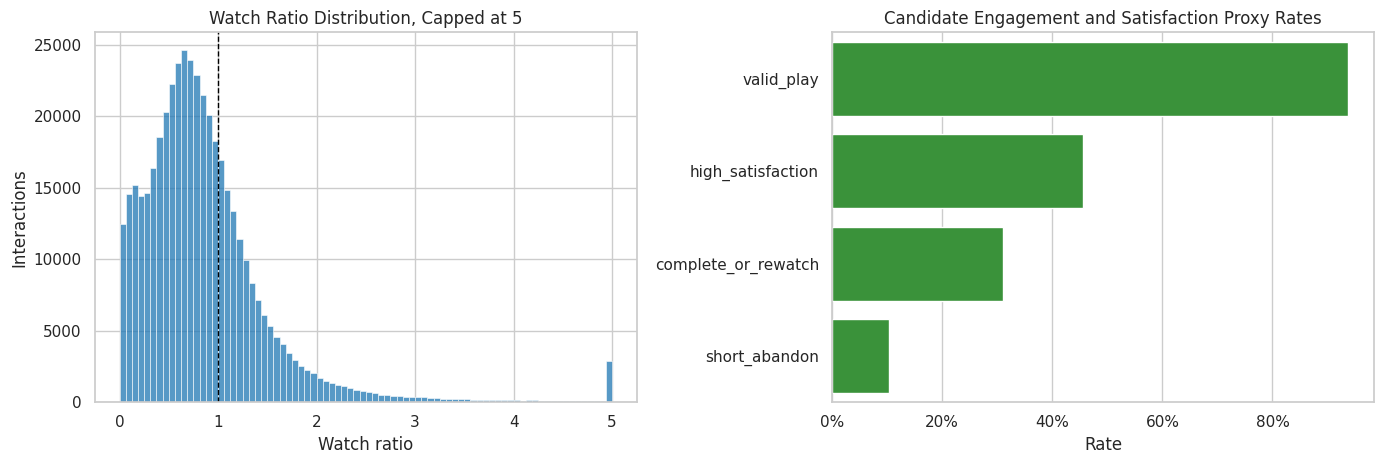

In [7]:
# Plot watch ratio and satisfaction proxies.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.histplot(interactions["watch_ratio_capped_5"], bins=80, ax=axes[0], color="tab:blue")
axes[0].axvline(1.0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Watch Ratio Distribution, Capped at 5")
axes[0].set_xlabel("Watch ratio")
axes[0].set_ylabel("Interactions")

proxy_rates = pd.DataFrame(
    {
        "proxy": ["valid_play", "high_satisfaction", "complete_or_rewatch", "short_abandon"],
        "rate": [
            interactions["valid_play_proxy"].mean(),
            interactions["high_satisfaction_proxy"].mean(),
            interactions["complete_or_rewatch"].mean(),
            interactions["short_abandon_proxy"].mean(),
        ],
    }
)
sns.barplot(data=proxy_rates, x="rate", y="proxy", ax=axes[1], color="tab:green")
axes[1].set_title("Candidate Engagement and Satisfaction Proxy Rates")
axes[1].set_xlabel("Rate")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_watch_ratio_and_proxy_rates.png", dpi=160, bbox_inches="tight")
plt.show()


The plots show that satisfaction is richer than simple play occurrence. Most sampled rows are plays, so the more useful mediators are quality measures such as valid play, completion, high watch ratio, and abandonment.


### Create Item Discovery Features

This cell builds item-level features from the interaction sample and metadata. The important feature is `long_tail_item`, a proxy for discovery-oriented content. Because KuaiRec's small matrix can be close to dense across sampled users, sample interaction counts alone are not a good popularity measure here. We therefore define long-tail status from platform-level daily exposure counts (`avg_show_cnt`, with `avg_play_cnt` as a fallback), which better represents whether an item is broadly popular in the product environment.

In [8]:
# Create item discovery features.
item_sample_features = (
    interactions.groupby("video_id")
    .agg(
        sample_interactions=("user_id", "size"),
        sample_users=("user_id", "nunique"),
        sample_mean_watch_ratio=("watch_ratio_clean", "mean"),
        sample_high_satisfaction_rate=("high_satisfaction_proxy", "mean"),
        sample_complete_rate=("complete_or_rewatch", "mean"),
        sample_valid_play_rate=("valid_play_proxy", "mean"),
    )
    .reset_index()
)

item_daily_summary = (
    item_daily.groupby("video_id")
    .agg(
        daily_rows=("date", "size"),
        avg_show_cnt=("show_cnt", "mean"),
        avg_play_cnt=("play_cnt", "mean"),
        avg_play_progress=("play_progress", "mean"),
        avg_like_cnt=("like_cnt", "mean"),
        avg_share_cnt=("share_cnt", "mean"),
        avg_report_cnt=("report_cnt", "mean"),
        avg_reduce_similar_cnt=("reduce_similar_cnt", "mean"),
    )
    .reset_index()
)

item_features = (
    item_sample_features.merge(caption_categories, on="video_id", how="left")
    .merge(item_categories, on="video_id", how="left")
    .merge(item_daily_summary, on="video_id", how="left")
)

item_features["platform_popularity_score"] = (
    item_features["avg_show_cnt"]
    .combine_first(item_features["avg_play_cnt"])
    .combine_first(item_features["sample_interactions"].astype(float))
)
long_tail_threshold = item_features["platform_popularity_score"].quantile(0.40)
item_features["long_tail_item"] = (item_features["platform_popularity_score"] <= long_tail_threshold).astype("int8")
item_features["log_platform_popularity_score"] = np.log1p(item_features["platform_popularity_score"])
item_features["log_sample_interactions"] = np.log1p(item_features["sample_interactions"])
item_features["category_label"] = item_features["first_level_category_name"].fillna("unknown")

item_feature_summary = pd.DataFrame(
    {
        "metric": [
            "items_in_sample",
            "long_tail_threshold_platform_exposure",
            "long_tail_item_share",
            "categories_with_sampled_items",
            "items_missing_category",
            "sample_interaction_std",
            "platform_popularity_std",
        ],
        "value": [
            len(item_features),
            long_tail_threshold,
            item_features["long_tail_item"].mean(),
            item_features["category_label"].nunique(),
            item_features["first_level_category_name"].isna().sum(),
            item_features["sample_interactions"].std(),
            item_features["platform_popularity_score"].std(),
        ],
    }
)

display(item_feature_summary)
display(item_features.head())


,metric,value
0,items_in_sample,"3,327.0000"
1,long_tail_threshold_platform_exposure,"65,221.2390"
2,long_tail_item_share,0.4001
3,categories_with_sampled_items,39.0000
4,items_missing_category,2.0000
5,sample_interaction_std,1.6282
6,platform_popularity_std,"584,997.9819"


,video_id,sample_interactions,sample_users,sample_mean_watch_ratio,sample_high_satisfaction_rate,sample_complete_rate,sample_valid_play_rate,first_level_category_id,first_level_category_name,second_level_category_id,second_level_category_name,third_level_category_id,third_level_category_name,feat,daily_rows,avg_show_cnt,avg_play_cnt,avg_play_progress,avg_like_cnt,avg_share_cnt,avg_report_cnt,avg_reduce_similar_cnt,platform_popularity_score,long_tail_item,log_platform_popularity_score,log_sample_interactions,category_label
0,103,133,133,0.8032,0.3835,0.2105,0.9173,12.0000,美食,153.0000,美食教程,"1,460.0000",菜肴,[12],63,"109,310.6032","111,451.6190",0.5597,"1,549.2698",99.9524,0.0000,36.4444,"109,310.6032",0,11.6020,4.8978,美食
1,109,133,133,0.9869,0.6165,0.3835,0.9474,18.0000,汽车,716.0000,玩车,"2,510.0000",机车族,"[18, 5]",63,"21,251.9206","14,303.1905",0.5789,629.0476,2.2540,0.0000,5.6667,"21,251.9206",1,9.9642,4.8978,汽车
2,120,133,133,1.2237,0.7970,0.6767,0.9624,9.0000,喜剧,-124.0000,UNKNOWN,-124.0000,UNKNOWN,[9],63,"42,049.3492","41,847.3333",0.3802,"2,683.6349",39.4762,0.0000,23.4286,"42,049.3492",1,10.6466,4.8978,喜剧
3,122,133,133,0.8751,0.4662,0.2331,0.9474,9.0000,喜剧,548.0000,搞笑配音,-124.0000,UNKNOWN,[9],63,"11,721.7302","11,728.4127",0.6210,169.3016,3.8730,0.0000,4.4444,"11,721.7302",1,9.3693,4.8978,喜剧
4,128,133,133,0.7680,0.3383,0.1880,0.9323,12.0000,美食,292.0000,美食日常,"1,461.0000",美食分享,"[11, 12, 9]",63,"436,061.3175","446,937.2698",0.7127,"10,863.7937",62.5873,0.0635,235.0159,"436,061.3175",0,12.9855,4.8978,美食


The long-tail definition now uses platform exposure from the full data context. This matters because a causal setup needs treatment variation. If every active day had the same discovery exposure value, later mediation notebooks would have nothing meaningful to compare.

#### 9. Enrich Interactions with Discovery Context

This cell joins item features back to each interaction and creates row-level discovery indicators. A row is a discovery candidate if the video is long-tail or if the video category is new to that user at the time of interaction.


In [9]:
# Enrich interactions with discovery context.
interactions_enriched = interactions.merge(
    item_features[
        [
            "video_id",
            "category_label",
            "first_level_category_id",
            "second_level_category_id",
            "third_level_category_id",
            "sample_interactions",
            "sample_users",
            "sample_mean_watch_ratio",
            "sample_high_satisfaction_rate",
            "platform_popularity_score",
            "long_tail_item",
            "log_platform_popularity_score",
            "log_sample_interactions",
        ]
    ],
    on="video_id",
    how="left",
)

interactions_enriched = interactions_enriched.sort_values(["user_id", "event_time", "video_id"]).reset_index(drop=True)
interactions_enriched["user_category_seen_count"] = (
    interactions_enriched.groupby(["user_id", "category_label"]).cumcount()
)
interactions_enriched["new_category_for_user"] = (interactions_enriched["user_category_seen_count"] == 0).astype("int8")
interactions_enriched["discovery_candidate"] = (
    (interactions_enriched["long_tail_item"].fillna(0).eq(1))
    | (interactions_enriched["new_category_for_user"].eq(1))
).astype("int8")

interaction_discovery_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "long_tail_interaction_share",
            "new_category_interaction_share",
            "discovery_candidate_share",
            "unique_categories",
        ],
        "value": [
            len(interactions_enriched),
            interactions_enriched["long_tail_item"].mean(),
            interactions_enriched["new_category_for_user"].mean(),
            interactions_enriched["discovery_candidate"].mean(),
            interactions_enriched["category_label"].nunique(),
        ],
    }
)

display(interaction_discovery_summary)
display(interactions_enriched.head())


,metric,value
0,rows,"440,788.0000"
1,long_tail_interaction_share,0.4005
2,new_category_interaction_share,0.0118
3,discovery_candidate_share,0.4080
4,unique_categories,39.0000


,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio,event_time,event_date,event_timestamp,play_duration_sec,video_duration_sec,watch_ratio_clean,watch_ratio_capped_5,watch_ratio_capped_2,played_proxy,valid_play_proxy,high_satisfaction_proxy,complete_or_rewatch,short_abandon_proxy,satisfaction_score_proxy,category_label,first_level_category_id,second_level_category_id,third_level_category_id,sample_interactions,sample_users,sample_mean_watch_ratio,sample_high_satisfaction_rate,platform_popularity_score,long_tail_item,log_platform_popularity_score,log_sample_interactions,user_category_seen_count,new_category_for_user,discovery_candidate
0,120,5228,7174,9900,2020-07-05 07:01:50.19,"20,200,705.0000","1,593,903,710.1900",0.7246,2020-07-05 07:01:50.190,2020-07-05,2020-07-04 23:01:50.190000057,7.1740,9.9000,0.7246,0.7246,0.7246,1,1,0,0,0,0.4312,运动,7.0000,126.0000,"1,056.0000",133,133,0.8021,0.4586,"8,771.5818",1,9.0794,4.8978,0,1,1
1,120,6788,4685,14934,2020-07-05 07:05:40.676,"20,200,705.0000","1,593,903,940.6760",0.3137,2020-07-05 07:05:40.676,2020-07-05,2020-07-04 23:05:40.676000118,4.6850,14.9340,0.3137,0.3137,0.3137,1,1,0,0,0,0.3284,二次元,20.0000,712.0000,"2,491.0000",133,133,0.5268,0.0827,"42,667.4444",1,10.6612,4.8978,0,1,1
2,120,8207,4923,13834,2020-07-05 07:39:22.913,"20,200,705.0000","1,593,905,962.9130",0.3559,2020-07-05 07:39:22.913,2020-07-05,2020-07-04 23:39:22.913000107,4.9230,13.8340,0.3559,0.3559,0.3559,1,1,0,0,0,0.3390,喜剧,9.0000,136.0000,-124.0000,133,133,0.6196,0.2556,"590,545.6984",0,13.2888,4.8978,0,1,1
3,120,1936,3834,7100,2020-07-05 08:24:57.112,"20,200,705.0000","1,593,908,697.1120",0.5400,2020-07-05 08:24:57.112,2020-07-05,2020-07-05 00:24:57.111999989,3.8340,7.1000,0.5400,0.5400,0.5400,1,1,0,0,0,0.3850,运动,7.0000,126.0000,"1,056.0000",132,132,1.2257,0.8030,"13,711.4921",1,9.5261,4.8903,1,0,1
4,120,5266,6110,7074,2020-07-05 08:34:43.594,"20,200,705.0000","1,593,909,283.5940",0.8637,2020-07-05 08:34:43.594,2020-07-05,2020-07-05 00:34:43.594000101,6.1100,7.0740,0.8637,0.8637,0.8637,1,1,1,0,0,0.4659,宠物,17.0000,-124.0000,-124.0000,133,133,1.2875,0.7519,"34,720.4127",1,10.4551,4.8978,0,1,1


This row-level discovery marker is the bridge from EDA to causal design. It represents exposure to content that is either less popular or less familiar to the user. The later mediation notebook can test whether this exposure works through immediate engagement and satisfaction.


#### 10. Plot Content Popularity and Discovery Exposure

This cell visualizes item popularity and discovery exposure. The popularity distribution shows whether there is a meaningful long tail, and the category plot shows where discovery-candidate interactions occur.


/tmp/ipykernel_1735118/1936025339.py:24: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1735118/1936025339.py:24: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1735118/1936025339.py:24: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1735118/1936025339.py:24: UserWarning: Glyph 30721 (\N{CJK UNIFIED IDEOGRAPH-7801}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1735118/1936025339.py:24: UserWarning: Glyph 39068 (\N{CJK UNIFIED IDEOGRAPH-989C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1735118/1936025339.py:24: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1735118/1936025339.py:24: UserWarning: Glyph 36816 (\N{CJK UN

/home/apex/Documents/portfolio/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/apex/Documents/portfolio/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/apex/Documents/portfolio/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/apex/Documents/portfolio/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30721 (\N{CJK UNIFIED IDEOGRAPH-7801}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/apex/Documents/portfolio/.venv/lib/python3.11/site-packages/IPytho

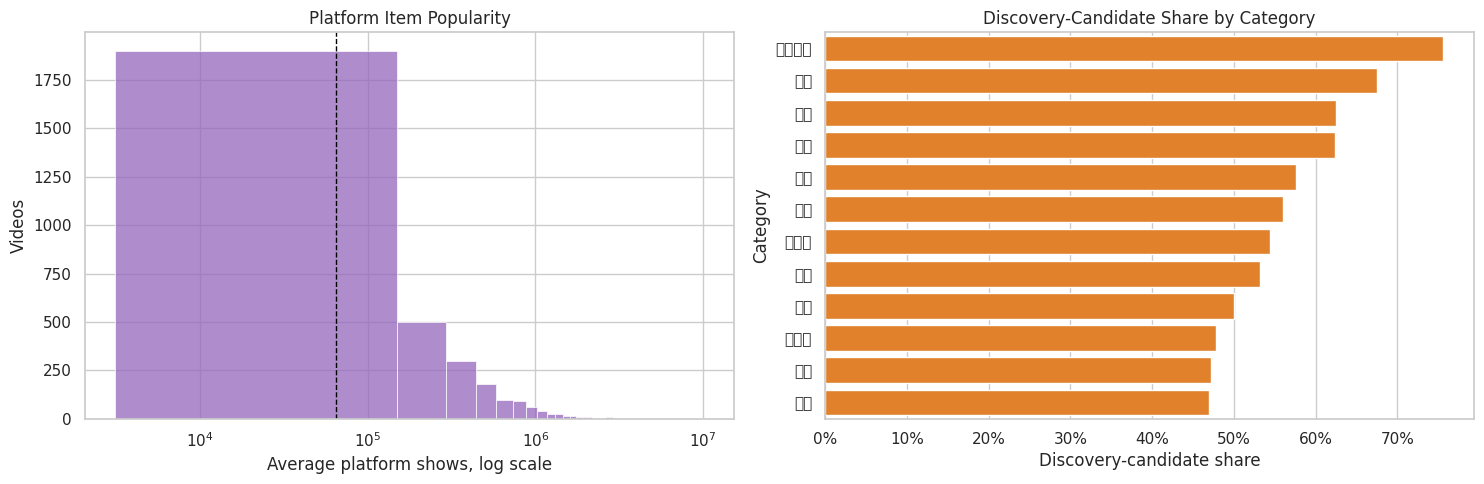

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(item_features["platform_popularity_score"], bins=70, ax=axes[0], color="tab:purple")
axes[0].set_xscale("log")
axes[0].axvline(long_tail_threshold, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Platform Item Popularity")
axes[0].set_xlabel("Average platform shows, log scale")
axes[0].set_ylabel("Videos")

category_discovery = (
    interactions_enriched.groupby("category_label")
    .agg(rows=("video_id", "size"), discovery_share=("discovery_candidate", "mean"))
    .reset_index()
    .query("rows >= 500")
    .sort_values("discovery_share", ascending=False)
    .head(12)
)
sns.barplot(data=category_discovery, x="discovery_share", y="category_label", ax=axes[1], color="tab:orange")
axes[1].set_title("Discovery-Candidate Share by Category")
axes[1].set_xlabel("Discovery-candidate share")
axes[1].set_ylabel("Category")
axes[1].xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_popularity_and_discovery_exposure.png", dpi=160, bbox_inches="tight")
plt.show()


The plots confirm that discovery exposure has real variation. That is necessary for mediation: if every user-day had the same discovery exposure level, we could not study whether it changes engagement, satisfaction, or future activity.


### Build a Balanced User-Day Panel

Mediation will be easier to define at the user-day level. This cell aggregates interactions into daily measures, then creates a balanced user-date panel so inactive future days are counted as zero activity.


In [11]:
# Build a balanced user-day panel.
daily_observed = (
    interactions_enriched.groupby(["user_id", "event_date"])
    .agg(
        interactions=("video_id", "size"),
        unique_videos=("video_id", "nunique"),
        unique_categories=("category_label", "nunique"),
        total_play_duration_sec=("play_duration_sec", "sum"),
        avg_play_duration_sec=("play_duration_sec", "mean"),
        avg_video_duration_sec=("video_duration_sec", "mean"),
        avg_watch_ratio=("watch_ratio_clean", "mean"),
        avg_watch_ratio_capped_2=("watch_ratio_capped_2", "mean"),
        valid_play_share=("valid_play_proxy", "mean"),
        high_satisfaction_share=("high_satisfaction_proxy", "mean"),
        complete_or_rewatch_share=("complete_or_rewatch", "mean"),
        short_abandon_share=("short_abandon_proxy", "mean"),
        avg_satisfaction_score=("satisfaction_score_proxy", "mean"),
        long_tail_share=("long_tail_item", "mean"),
        new_category_share=("new_category_for_user", "mean"),
        discovery_candidate_share=("discovery_candidate", "mean"),
    )
    .reset_index()
)

date_index = pd.date_range(interactions_enriched["event_date"].min(), interactions_enriched["event_date"].max(), freq="D")
user_index = np.sort(interactions_enriched["user_id"].unique())
balanced_index = pd.MultiIndex.from_product([user_index, date_index], names=["user_id", "event_date"])
user_day = balanced_index.to_frame(index=False).merge(daily_observed, on=["user_id", "event_date"], how="left")

count_cols = ["interactions", "unique_videos", "unique_categories", "total_play_duration_sec"]
share_cols = [
    "avg_play_duration_sec",
    "avg_video_duration_sec",
    "avg_watch_ratio",
    "avg_watch_ratio_capped_2",
    "valid_play_share",
    "high_satisfaction_share",
    "complete_or_rewatch_share",
    "short_abandon_share",
    "avg_satisfaction_score",
    "long_tail_share",
    "new_category_share",
    "discovery_candidate_share",
]
for col in count_cols + share_cols:
    user_day[col] = user_day[col].fillna(0)

user_day["active_day"] = (user_day["interactions"] > 0).astype("int8")
user_day["calendar_day_index"] = (user_day["event_date"] - user_day["event_date"].min()).dt.days
user_day = user_day.sort_values(["user_id", "event_date"]).reset_index(drop=True)

panel_summary = pd.DataFrame(
    {
        "metric": [
            "users",
            "calendar_days",
            "panel_rows",
            "active_day_rate",
            "mean_interactions_on_active_days",
            "mean_discovery_share_on_active_days",
        ],
        "value": [
            user_day["user_id"].nunique(),
            user_day["event_date"].nunique(),
            len(user_day),
            user_day["active_day"].mean(),
            user_day.loc[user_day["active_day"].eq(1), "interactions"].mean(),
            user_day.loc[user_day["active_day"].eq(1), "discovery_candidate_share"].mean(),
        ],
    }
)

display(panel_summary)
display(user_day.head())


,metric,value
0,users,133.0000
1,calendar_days,63.0000
2,panel_rows,"8,379.0000"
3,active_day_rate,0.9785
4,mean_interactions_on_active_days,51.6097
5,mean_discovery_share_on_active_days,0.3644


,user_id,event_date,interactions,unique_videos,unique_categories,total_play_duration_sec,avg_play_duration_sec,avg_video_duration_sec,avg_watch_ratio,avg_watch_ratio_capped_2,valid_play_share,high_satisfaction_share,complete_or_rewatch_share,short_abandon_share,avg_satisfaction_score,long_tail_share,new_category_share,discovery_candidate_share,active_day,calendar_day_index
0,120,2020-07-05,32.0000,32.0000,16.0000,163.9700,5.1241,11.9891,0.5813,0.5813,0.9375,0.1562,0.0938,0.0625,0.4031,0.4062,0.5000,0.6875,1,0
1,120,2020-07-06,20.0000,20.0000,15.0000,130.9860,6.5493,13.4448,0.6965,0.6837,0.9500,0.3500,0.2000,0.1500,0.4584,0.3500,0.2500,0.4500,1,1
2,120,2020-07-07,16.0000,16.0000,10.0000,100.9200,6.3075,10.1208,0.6580,0.6580,1.0000,0.1875,0.0625,0.0000,0.4301,0.2500,0.3125,0.4375,1,2
3,120,2020-07-08,37.0000,37.0000,23.0000,222.7200,6.0195,21.1131,0.5842,0.5639,0.8919,0.2162,0.0541,0.2703,0.3775,0.3514,0.1351,0.4324,1,3
4,120,2020-07-09,34.0000,34.0000,14.0000,230.6110,6.7827,11.9327,0.6982,0.6982,1.0000,0.3235,0.2059,0.0294,0.4760,0.3824,0.0000,0.3824,1,4


The balanced panel is the core data structure for this project. It preserves inactive days, which matters for future engagement outcomes. It also summarizes discovery exposure and satisfaction on the same user-day.


#### 12. Define Future Outcomes and History Controls

This cell creates future outcomes and lagged history controls. Later mediation models should adjust for prior user behavior because users with different histories may receive different exposure and have different future engagement.


In [12]:
# Define future outcomes and history controls.
def future_sum_by_user(frame, column, horizon):
    """
    Compute future-horizon sums within each KuaiRec user history.
    
    Idea
    ----
    The helper creates forward-looking outcomes such as future interactions or future play duration while preserving user-level temporal ordering.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    column : object
        Name of the column being transformed or summarized.
    horizon : object
        Number of future periods to include in the rolling sum.
    
    Returns
    -------
    pandas.Series
        Future-horizon sum aligned with the input frame.
    """
    pieces = []
    grouped = frame.groupby("user_id", sort=False)[column]
    total = pd.Series(0.0, index=frame.index)
    for step in range(1, horizon + 1):
        total = total + grouped.shift(-step).fillna(0)
    return total

for col in ["active_day", "interactions", "total_play_duration_sec"]:
    user_day[f"lead_1_{col}"] = user_day.groupby("user_id")[col].shift(-1).fillna(0)
    user_day[f"future_3day_{col}"] = future_sum_by_user(user_day, col, 3)
    user_day[f"future_7day_{col}"] = future_sum_by_user(user_day, col, 7)

for col in [
    "active_day",
    "interactions",
    "total_play_duration_sec",
    "avg_watch_ratio_capped_2",
    "valid_play_share",
    "high_satisfaction_share",
    "discovery_candidate_share",
]:
    user_day[f"lag_1_{col}"] = user_day.groupby("user_id")[col].shift(1).fillna(0)
    user_day[f"prior_3day_{col}"] = (
        user_day.groupby("user_id")[col]
        .rolling(window=3, min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
        .groupby(user_day["user_id"])
        .shift(1)
        .fillna(0)
    )

future_summary = user_day[
    [
        "future_7day_active_day",
        "future_7day_interactions",
        "future_7day_total_play_duration_sec",
        "lag_1_interactions",
        "prior_3day_interactions",
    ]
].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).T

display(future_summary)


,count,mean,std,min,25%,50%,75%,90%,max
future_7day_active_day,"8,379.0000",6.4157,1.5444,0.0000,7.0000,7.0000,7.0000,7.0000,7.0000
future_7day_interactions,"8,379.0000",338.3823,182.2699,0.0000,202.0000,364.0000,470.0000,561.0000,899.0000
future_7day_total_play_duration_sec,"8,379.0000","2,926.6982","1,698.1722",0.0000,"1,726.1070","2,953.5820","4,037.2785","5,032.7692","10,442.1170"
lag_1_interactions,"8,379.0000",50.4739,32.3121,0.0000,27.0000,47.0000,69.0000,93.0000,293.0000
prior_3day_interactions,"8,379.0000",151.1738,79.6062,0.0000,92.0000,149.0000,203.0000,254.0000,497.0000


The future outcomes provide the retention side of the mediation pathway. The lagged variables are not causal results; they are adjustment candidates that help later models compare similar user-days.


### Define Treatment, Mediators, and Outcome Candidates

This cell creates first-pass variables for the mediation analysis. The treatment is high discovery exposure on an active day. The mediators are same-day engagement quality and satisfaction. The outcome is future 7-day engagement.


In [13]:
# Define treatment, mediators, and outcome candidates.
active_days = user_day.query("active_day == 1").copy()
discovery_threshold = active_days["discovery_candidate_share"].median()
long_tail_threshold_day = active_days["long_tail_share"].median()

user_day["treatment_high_discovery_exposure"] = (
    (user_day["active_day"].eq(1))
    & (user_day["discovery_candidate_share"] >= discovery_threshold)
).astype("int8")
user_day["treatment_high_long_tail_exposure"] = (
    (user_day["active_day"].eq(1))
    & (user_day["long_tail_share"] >= long_tail_threshold_day)
).astype("int8")

user_day["mediator_valid_play_share"] = user_day["valid_play_share"]
user_day["mediator_high_satisfaction_share"] = user_day["high_satisfaction_share"]
user_day["mediator_avg_satisfaction_score"] = user_day["avg_satisfaction_score"]
user_day["outcome_future_7day_interactions"] = user_day["future_7day_interactions"]
user_day["outcome_future_7day_active_days"] = user_day["future_7day_active_day"]
user_day["outcome_future_7day_play_hours"] = user_day["future_7day_total_play_duration_sec"] / 3600

mediation_panel = user_day.query("active_day == 1").copy()
mediation_panel = mediation_panel.merge(
    user_features,
    on="user_id",
    how="left",
)

candidate_summary = pd.DataFrame(
    [
        {
            "role": "treatment",
            "variable": "treatment_high_discovery_exposure",
            "mean": mediation_panel["treatment_high_discovery_exposure"].mean(),
            "description": "Active user-day has discovery-candidate share at or above the active-day median, where discovery combines platform long-tail status and first category exposure.",
        },
        {
            "role": "treatment_alt",
            "variable": "treatment_high_long_tail_exposure",
            "mean": mediation_panel["treatment_high_long_tail_exposure"].mean(),
            "description": "Active user-day has long-tail share at or above the active-day median.",
        },
        {
            "role": "mediator_engagement",
            "variable": "mediator_valid_play_share",
            "mean": mediation_panel["mediator_valid_play_share"].mean(),
            "description": "Share of interactions that look like valid plays.",
        },
        {
            "role": "mediator_satisfaction",
            "variable": "mediator_high_satisfaction_share",
            "mean": mediation_panel["mediator_high_satisfaction_share"].mean(),
            "description": "Share of interactions with watch ratio at least 0.8.",
        },
        {
            "role": "outcome",
            "variable": "outcome_future_7day_interactions",
            "mean": mediation_panel["outcome_future_7day_interactions"].mean(),
            "description": "Future 7-day interaction count after the current day.",
        },
        {
            "role": "outcome_alt",
            "variable": "outcome_future_7day_active_days",
            "mean": mediation_panel["outcome_future_7day_active_days"].mean(),
            "description": "Future 7-day active-day count after the current day.",
        },
    ]
)

display(candidate_summary)
display(mediation_panel.head())


,role,variable,mean,description
0,treatment,treatment_high_discovery_exposure,0.5015,Active user-day has discovery-candidate share ...
1,treatment_alt,treatment_high_long_tail_exposure,0.5001,Active user-day has long-tail share at or abov...
2,mediator_engagement,mediator_valid_play_share,0.9394,Share of interactions that look like valid plays.
3,mediator_satisfaction,mediator_high_satisfaction_share,0.4686,Share of interactions with watch ratio at leas...
4,outcome,outcome_future_7day_interactions,340.6945,Future 7-day interaction count after the curre...
5,outcome_alt,outcome_future_7day_active_days,6.4664,Future 7-day active-day count after the curren...


,user_id,event_date,interactions,unique_videos,unique_categories,total_play_duration_sec,avg_play_duration_sec,avg_video_duration_sec,avg_watch_ratio,avg_watch_ratio_capped_2,valid_play_share,high_satisfaction_share,complete_or_rewatch_share,short_abandon_share,avg_satisfaction_score,long_tail_share,new_category_share,discovery_candidate_share,active_day,calendar_day_index,lead_1_active_day,future_3day_active_day,future_7day_active_day,lead_1_interactions,future_3day_interactions,future_7day_interactions,lead_1_total_play_duration_sec,future_3day_total_play_duration_sec,future_7day_total_play_duration_sec,lag_1_active_day,prior_3day_active_day,lag_1_interactions,prior_3day_interactions,lag_1_total_play_duration_sec,prior_3day_total_play_duration_sec,lag_1_avg_watch_ratio_capped_2,prior_3day_avg_watch_ratio_capped_2,lag_1_valid_play_share,prior_3day_valid_play_share,lag_1_high_satisfaction_share,prior_3day_high_satisfaction_share,lag_1_discovery_candidate_share,prior_3day_discovery_candidate_share,treatment_high_discovery_exposure,treatment_high_long_tail_exposure,mediator_valid_play_share,mediator_high_satisfaction_share,mediator_avg_satisfaction_score,outcome_future_7day_interactions,outcome_future_7day_active_days,outcome_future_7day_play_hours,user_active_degree,is_lowactive_period,is_live_streamer,is_video_author,follow_user_num,follow_user_num_range,fans_user_num,fans_user_num_range,friend_user_num,friend_user_num_range,register_days,register_days_range,onehot_feat0,onehot_feat1,onehot_feat2,onehot_feat3,onehot_feat4,onehot_feat5,onehot_feat6,onehot_feat7,onehot_feat8,onehot_feat9,onehot_feat10,onehot_feat11,onehot_feat12,onehot_feat13,onehot_feat14,onehot_feat15,onehot_feat16,onehot_feat17
0,120,2020-07-05,32.0000,32.0000,16.0000,163.9700,5.1241,11.9891,0.5813,0.5813,0.9375,0.1562,0.0938,0.0625,0.4031,0.4062,0.5000,0.6875,1,0,1.0000,3.0000,7.0000,20.0000,73.0000,316.0000,130.9860,454.6260,"1,945.6300",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,1,0.9375,0.1562,0.4031,316.0000,7.0000,0.5405,full_active,0,0,0,7,"(0,10]",3,"[1,10)",0,0,224,181-365,0,1,24,876,1.0000,0,1,4,98,6,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,120,2020-07-06,20.0000,20.0000,15.0000,130.9860,6.5493,13.4448,0.6965,0.6837,0.9500,0.3500,0.2000,0.1500,0.4584,0.3500,0.2500,0.4500,1,1,1.0000,3.0000,7.0000,16.0000,87.0000,345.0000,100.9200,554.2510,"2,111.7460",1.0000,1.0000,32.0000,32.0000,163.9700,163.9700,0.5813,0.5813,0.9375,0.9375,0.1562,0.1562,0.6875,0.6875,1,0,0.9500,0.3500,0.4584,345.0000,7.0000,0.5866,full_active,0,0,0,7,"(0,10]",3,"[1,10)",0,0,224,181-365,0,1,24,876,1.0000,0,1,4,98,6,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,120,2020-07-07,16.0000,16.0000,10.0000,100.9200,6.3075,10.1208,0.6580,0.6580,1.0000,0.1875,0.0625,0.0000,0.4301,0.2500,0.3125,0.4375,1,2,1.0000,3.0000,7.0000,37.0000,128.0000,393.0000,222.7200,789.3200,"2,417.3040",1.0000,2.0000,20.0000,52.0000,130.9860,294.9560,0.6837,1.2650,0.9500,1.8875,0.3500,0.5062,0.4500,1.1375,1,0,1.0000,0.1875,0.4301,393.0000,7.0000,0.6715,full_active,0,0,0,7,"(0,10]",3,"[1,10)",0,0,224,181-365,0,1,24,876,1.0000,0,1,4,98,6,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,120,2020-07-08,37.0000,37.0000,23.0000,222.7200,6.0195,21.1131,0.5842,0.5639,0.8919,0.2162,0.0541,0.2703,0.3775,0.3514,0.1351,0.4324,1,3,1.0000,3.0000,7.0000,34.0000,144.0000,436.0000,230.6110,894.1200,"2,725.9950",1.0000,3.0000,16.0000,68.0000,100.9200,395.8760,0.6580,1.9230,1.0000,2.8875,0.1875,0.6937,0.4375,1.5750,1,0,0.8919,0.2162,0.3775,436.0000,7.0000,0.7572,full_active,0,0,0,7,"(0,10]",3,"[1,10)",0,0,224,181-365,0,1,24,876,1.0000,0,1,4,98,6,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,120,2020-07-09,34.0000,34.0000,14.0000,230.6110,6.7827,11.9327,0.6982,0.6982,1.0000,0.3235,0.2059,0.0294,0.4760,0.3824,0.0000,0.3824,1,4,1.0000,3.0000,7.0000,57.0000,209.0000,448.0000,335.9890,"1,260.3930","2,809.6920",1.0000,3.0000,37.0000,73.0000,222.7200,454.6260,0.5639,1.9056,

This table is the first explicit mediation setup. It does not prove causality yet. It defines a plausible treatment, mediators, and future outcomes so the next notebook can validate and refine the metric choices.


#### 14. Compare Same-Day Metrics by Discovery Exposure

This cell compares mediators and future outcomes between high-discovery and lower-discovery active days. These raw differences help us see whether the variables have meaningful variation before adjustment.


In [14]:
# Compare same-day metrics by discovery exposure.
comparison_metrics = [
    "interactions",
    "valid_play_share",
    "high_satisfaction_share",
    "complete_or_rewatch_share",
    "avg_satisfaction_score",
    "outcome_future_7day_interactions",
    "outcome_future_7day_active_days",
    "outcome_future_7day_play_hours",
    "lag_1_interactions",
    "prior_3day_interactions",
]

raw_means = mediation_panel.groupby("treatment_high_discovery_exposure")[comparison_metrics].mean()
for arm in [0, 1]:
    if arm not in raw_means.index:
        raw_means.loc[arm] = np.nan
raw_means = raw_means.sort_index()

raw_comparison = pd.DataFrame(
    {
        "metric": comparison_metrics,
        "lower_discovery_days": raw_means.loc[0, comparison_metrics].to_numpy(),
        "high_discovery_days": raw_means.loc[1, comparison_metrics].to_numpy(),
    }
)
raw_comparison["high_minus_lower"] = raw_comparison["high_discovery_days"] - raw_comparison["lower_discovery_days"]

display(raw_comparison)


,metric,lower_discovery_days,high_discovery_days,high_minus_lower
0,interactions,39.6538,63.4929,23.8392
1,valid_play_share,0.9377,0.9411,0.0033
2,high_satisfaction_share,0.4538,0.4834,0.0296
3,complete_or_rewatch_share,0.3138,0.3324,0.0185
4,avg_satisfaction_score,0.5187,0.5295,0.0108
5,outcome_future_7day_interactions,247.8894,432.9353,185.0459
6,outcome_future_7day_active_days,6.0595,6.8709,0.8114
7,outcome_future_7day_play_hours,0.6040,1.0326,0.4286
8,lag_1_interactions,41.1461,60.8570,19.7109
9,prior_3day_interactions,126.5388,178.4667,51.9279


Raw differences are useful for orientation. If high-discovery days also have very different prior activity, later mediation models need adjustment. The next notebooks should not interpret these simple differences as causal effects.


#### 15. Plot Treatment, Mediators, and Future Outcome Relationships

This cell creates a compact visual summary of how discovery exposure relates to same-day satisfaction and future engagement. It is meant as EDA, not causal evidence.


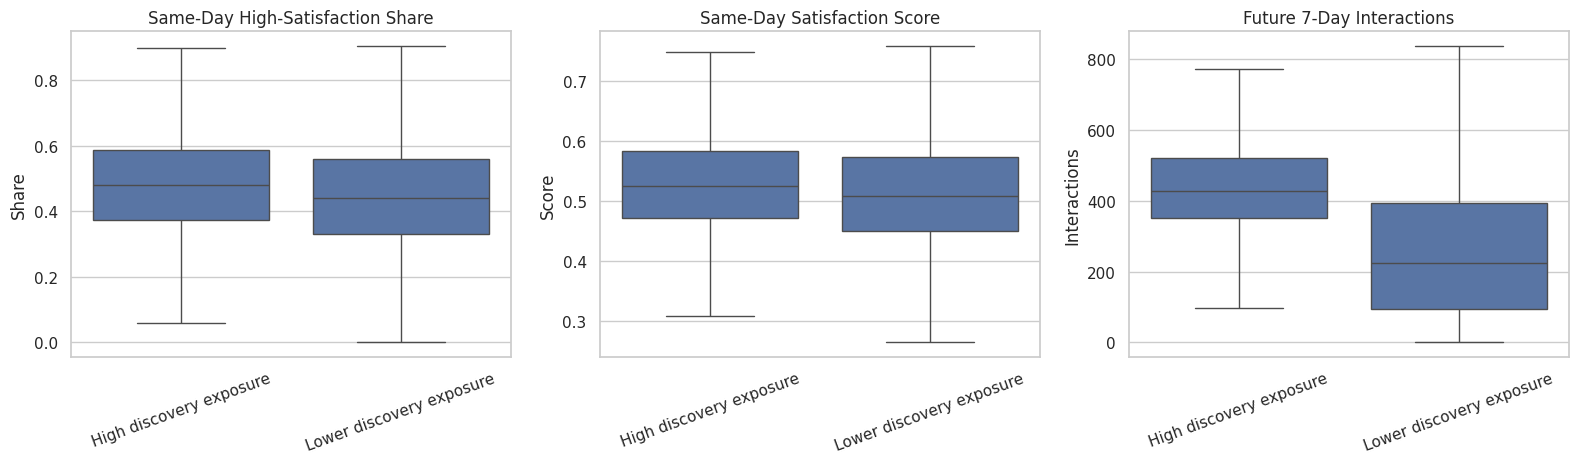

In [15]:
# Plot treatment, mediators, and future outcome relationships.
plot_df = mediation_panel.copy()
plot_df["discovery_group"] = plot_df["treatment_high_discovery_exposure"].map(
    {0: "Lower discovery exposure", 1: "High discovery exposure"}
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.boxplot(
    data=plot_df,
    x="discovery_group",
    y="mediator_high_satisfaction_share",
    ax=axes[0],
    showfliers=False,
)
axes[0].set_title("Same-Day High-Satisfaction Share")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=plot_df,
    x="discovery_group",
    y="mediator_avg_satisfaction_score",
    ax=axes[1],
    showfliers=False,
)
axes[1].set_title("Same-Day Satisfaction Score")
axes[1].set_xlabel("")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=plot_df,
    x="discovery_group",
    y="outcome_future_7day_interactions",
    ax=axes[2],
    showfliers=False,
)
axes[2].set_title("Future 7-Day Interactions")
axes[2].set_xlabel("")
axes[2].set_ylabel("Interactions")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_discovery_mediator_outcome_relationships.png", dpi=160, bbox_inches="tight")
plt.show()


The plots show the measurement pathway in one place: discovery exposure, satisfaction-like mediators, and future engagement. This helps check whether the later mediation analysis will be numerically meaningful.


#### 16. Correlation Map for Candidate Variables

This cell computes correlations among treatment, mediators, outcomes, and prior-history controls. Correlation helps diagnose variable redundancy and expected model behavior.


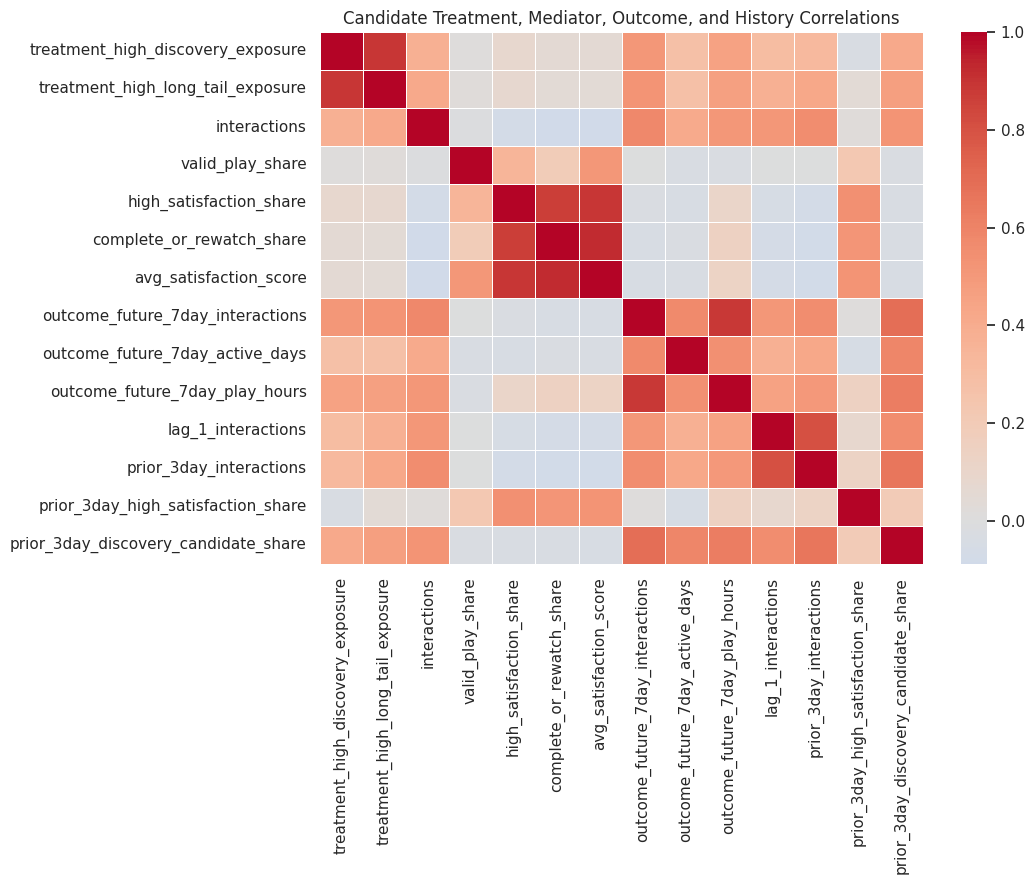

,treatment_high_discovery_exposure,treatment_high_long_tail_exposure,interactions,valid_play_share,high_satisfaction_share,complete_or_rewatch_share,avg_satisfaction_score,outcome_future_7day_interactions,outcome_future_7day_active_days,outcome_future_7day_play_hours,lag_1_interactions,prior_3day_interactions,prior_3day_high_satisfaction_share,prior_3day_discovery_candidate_share
treatment_high_discovery_exposure,1.0000,0.8900,0.3760,0.0170,0.0840,0.0540,0.0530,0.5130,0.2790,0.4580,0.3070,0.3280,-0.0340,0.4170
treatment_high_long_tail_exposure,0.8900,1.0000,0.4210,0.0190,0.0740,0.0410,0.0410,0.5260,0.2800,0.4680,0.3760,0.4260,0.0450,0.4750
interactions,0.3760,0.4210,1.0000,-0.0140,-0.0700,-0.0880,-0.0860,0.5800,0.4120,0.5150,0.5150,0.5590,0.0270,0.5290
valid_play_share,0.0170,0.0190,-0.0140,1.0000,0.3460,0.1920,0.5130,-0.0050,-0.0300,-0.0240,-0.0070,-0.0050,0.2240,-0.0260
high_satisfaction_share,0.0840,0.0740,-0.0700,0.3460,1.0000,0.8670,0.8920,-0.0270,-0.0380,0.1110,-0.0530,-0.0690,0.5380,-0.0300
complete_or_rewatch_share,0.0540,0.0410,-0.0880,0.1920,0.8670,1.0000,0.9230,-0.0460,-0.0230,0.1420,-0.0630,-0.0820,0.5160,-0.0320
avg_satisfaction_score,0.0530,0.0410,-0.0860,0.5130,0.8920,0.9230,1.0000,-0.0400,-0.0320,0.1310,-0.0620,-0.0800,0.5280,-0.0460
outcome_future_7day_interactions,0.5130,0.5260,0.5800,-0.0050,-0.0270,-0.0460,-0.0400,1.0000,0.5770,0.8810,0.5110,0.5610,0.0110,0.6930
outcome_future_7day_active_days,0.2790,0.2800,0.4120,-0.0300,-0.0380,-0.0230,-0.0320,0.5770,1.0000,0.5380,0.3780,0.4230,-0.0500,0.5830
outcome_future_7day_play_hours,0.4580,0.4680,0.5150,-0.0240,0.1110,0.1420,0.1310,0.8810,0.5380,1.0000,0.4580,0.5040,0.1440,0.6270


In [16]:
correlation_columns = [
    "treatment_high_discovery_exposure",
    "treatment_high_long_tail_exposure",
    "interactions",
    "valid_play_share",
    "high_satisfaction_share",
    "complete_or_rewatch_share",
    "avg_satisfaction_score",
    "outcome_future_7day_interactions",
    "outcome_future_7day_active_days",
    "outcome_future_7day_play_hours",
    "lag_1_interactions",
    "prior_3day_interactions",
    "prior_3day_high_satisfaction_share",
    "prior_3day_discovery_candidate_share",
]

correlation_matrix = mediation_panel[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, linewidths=0.5, ax=ax)
ax.set_title("Candidate Treatment, Mediator, Outcome, and History Correlations")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_candidate_variable_correlation_map.png", dpi=160, bbox_inches="tight")
plt.show()

display(correlation_matrix.round(3))


The correlation map helps identify which variables are likely to act as confounders or redundant mediators. In particular, prior activity variables should be treated carefully because they can predict both current exposure and future outcomes.


## Readiness Checks for Mediation Analysis

This cell summarizes whether the constructed panel is ready for the next notebook. It checks sample size, treatment variation, mediator variation, future-outcome variation, and missingness in key variables.


In [17]:
# Prepare readiness checks for mediation analysis.
key_variables = [
    "treatment_high_discovery_exposure",
    "mediator_valid_play_share",
    "mediator_high_satisfaction_share",
    "mediator_avg_satisfaction_score",
    "outcome_future_7day_interactions",
    "outcome_future_7day_active_days",
    "lag_1_interactions",
    "prior_3day_interactions",
]

readiness_checks = pd.DataFrame(
    [
        {
            "check": "active_user_days",
            "value": len(mediation_panel),
            "notes": "Rows available for active-day mediation setup.",
        },
        {
            "check": "sampled_users",
            "value": mediation_panel["user_id"].nunique(),
            "notes": "Users represented in the mediation panel.",
        },
        {
            "check": "treatment_rate",
            "value": mediation_panel["treatment_high_discovery_exposure"].mean(),
            "notes": "Should be neither near 0 nor near 1.",
        },
        {
            "check": "mediator_satisfaction_std",
            "value": mediation_panel["mediator_high_satisfaction_share"].std(),
            "notes": "Mediator must vary across user-days.",
        },
        {
            "check": "future_7day_interactions_std",
            "value": mediation_panel["outcome_future_7day_interactions"].std(),
            "notes": "Outcome must vary across user-days.",
        },
        {
            "check": "max_key_variable_missing_rate",
            "value": mediation_panel[key_variables].isna().mean().max(),
            "notes": "Key variables should be complete or nearly complete.",
        },
    ]
)

display(readiness_checks)


,check,value,notes
0,active_user_days,"8,199.0000",Rows available for active-day mediation setup.
1,sampled_users,133.0000,Users represented in the mediation panel.
2,treatment_rate,0.5015,Should be neither near 0 nor near 1.
3,mediator_satisfaction_std,0.1766,Mediator must vary across user-days.
4,future_7day_interactions_std,180.3633,Outcome must vary across user-days.
5,max_key_variable_missing_rate,0.0000,Key variables should be complete or nearly com...


The readiness checks should support moving to metric construction. If treatment, mediators, or future outcomes lacked variation, mediation would be weak. Here the panel has enough structure for the next notebook to compare candidate discovery-quality metrics.


#### 18. Save Processed Discovery-Quality Artifacts

This cell saves the processed interaction sample, item features, user-day panel, mediation panel, candidate variable summary, and readiness checks. Later notebooks can load these directly.


In [18]:
# Save processed discovery-Quality artifacts.
INTERACTIONS_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_interactions_sample.parquet"
ITEM_FEATURES_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_item_features.parquet"
USER_DAY_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_user_day_panel.parquet"
MEDIATION_PANEL_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_mediation_panel.parquet"
CANDIDATE_SUMMARY_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_candidate_variables.csv"
READINESS_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_readiness.csv"
RAW_COMPARISON_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_raw_comparison.csv"

interactions_enriched.to_parquet(INTERACTIONS_OUTPUT, index=False)
item_features.to_parquet(ITEM_FEATURES_OUTPUT, index=False)
user_day.to_parquet(USER_DAY_OUTPUT, index=False)
mediation_panel.to_parquet(MEDIATION_PANEL_OUTPUT, index=False)
candidate_summary.to_csv(CANDIDATE_SUMMARY_OUTPUT, index=False)
readiness_checks.to_csv(READINESS_OUTPUT, index=False)
raw_comparison.to_csv(RAW_COMPARISON_OUTPUT, index=False)

saved_outputs = pd.DataFrame(
    {
        "artifact": [
            "interactions_sample",
            "item_features",
            "user_day_panel",
            "mediation_panel",
            "candidate_variable_summary",
            "readiness_checks",
            "raw_discovery_comparison",
        ],
        "path": [
            str(INTERACTIONS_OUTPUT),
            str(ITEM_FEATURES_OUTPUT),
            str(USER_DAY_OUTPUT),
            str(MEDIATION_PANEL_OUTPUT),
            str(CANDIDATE_SUMMARY_OUTPUT),
            str(READINESS_OUTPUT),
            str(RAW_COMPARISON_OUTPUT),
        ],
    }
)

display(saved_outputs)


,artifact,path
0,interactions_sample,/home/apex/Documents/portfolio/data/processed/...
1,item_features,/home/apex/Documents/portfolio/data/processed/...
2,user_day_panel,/home/apex/Documents/portfolio/data/processed/...
3,mediation_panel,/home/apex/Documents/portfolio/data/processed/...
4,candidate_variable_summary,/home/apex/Documents/portfolio/data/processed/...
5,readiness_checks,/home/apex/Documents/portfolio/data/processed/...
6,raw_discovery_comparison,/home/apex/Documents/portfolio/data/processed/...


These saved files are the handoff to the next notebook. The mediation panel is the most important artifact because it contains treatment candidates, mediator candidates, future outcomes, and history controls in one user-day table.


### Takeaways and Next Step

This notebook established the data foundation for discovery-quality mediation:

- KuaiRec is a strong fit because it has watch duration, watch ratio, user features, item categories, and sequential user activity.
- The project should not treat play occurrence alone as satisfaction. Watch ratio, completion/rewatch, high-satisfaction share, and abandonment are richer signals.
- Discovery exposure can be represented by long-tail content and new-category content, then aggregated to a user-day treatment candidate.
- Future 7-day engagement can be measured with interactions, active days, and play hours.
- The next notebook should validate and refine the discovery-quality metric before formal mediation estimation.
